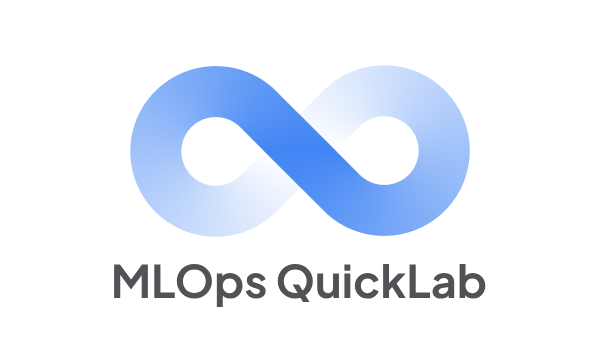

3. PyTorch를 통한 모델 서빙

In [1]:
!pip install datasets torchserve torch-model-archiver torch-workflow-archiver nvgpu

In [2]:
!pip install -U datasets

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification, BatchEncoding, BertTokenizer, BertForSequenceClassification
from sklearn.metrics import confusion_matrix
from datasets import load_dataset
from tqdm import tqdm
from typing import TypedDict

In [6]:
dataset = load_dataset("ag_news")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = torch.nn.CrossEntropyLoss()

class DatasetItem(TypedDict):
    text: str
    label: str


def preprocess_data(dataset_item: DatasetItem) -> dict[str, torch.Tensor]:
    return tokenizer(dataset_item["text"], truncation=True, padding="max_length", return_tensors="pt")


train_dataset = dataset["train"].select(range(1200)).map(preprocess_data, batched=True)
test_dataset = dataset["test"].select(range(800)).map(preprocess_data, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 3
losses: list[float] = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}, Average Loss: {average_loss}")

Epoch 1: 100%|██████████| 150/150 [01:43<00:00,  1.45it/s]


Epoch 1, Average Loss: 0.6750549754500389


Epoch 2: 100%|██████████| 150/150 [01:51<00:00,  1.35it/s]


Epoch 2, Average Loss: 0.3022286734978358


Epoch 3: 100%|██████████| 150/150 [01:50<00:00,  1.36it/s]

Epoch 3, Average Loss: 0.1779055491524438


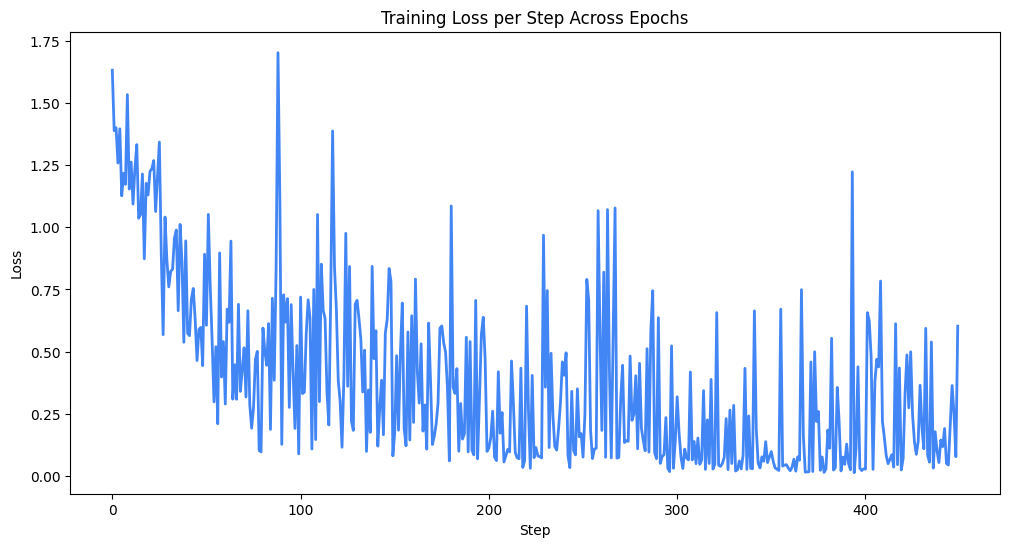

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(losses, color="#4285f4", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss per Step Across Epochs")
plt.show()

## 모델 평가

In [9]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs, labels=labels)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)
        correct += (predicted_labels == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print("")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Evaluating: 100%|██████████| 100/100 [00:23<00:00,  4.34it/s]


Test Accuracy: 84.50%


In [11]:
test_input = "Despite geopolitical uncertainties in the Middle East, Samsung Electronics and SK Hynix are once again approaching record highs, bolstered by the surge in U.S. tech stocks and strong earnings expectations. As signs of easing geopolitical risks emerge, investor sentiment has recovered rapidly, with the robust performance of large-cap semiconductor stocks leading the overall index upward."
test_input_processed = tokenizer(test_input, truncation=True, padding="max_length", return_tensors="pt").to(device)
logits = model(**test_input_processed).logits
print(logits)
predicted_labels = torch.argmax(logits, dim=1)

labeling_mapper = ["world", "sports", "business", "sci/tech"]
print(labeling_mapper[predicted_labels[0]])

tensor([[-1.3493, -3.4347,  3.2582,  1.7133]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
business


In [12]:
all_predictions: list[int] = []
all_labels: list[int] = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        inputs = {key: batch[key].to(device) for key in batch}
        labels = inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_labels = torch.argmax(logits, dim=1)

        all_predictions.extend(predicted_labels.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating: 100%|██████████| 100/100 [00:23<00:00,  4.26it/s]


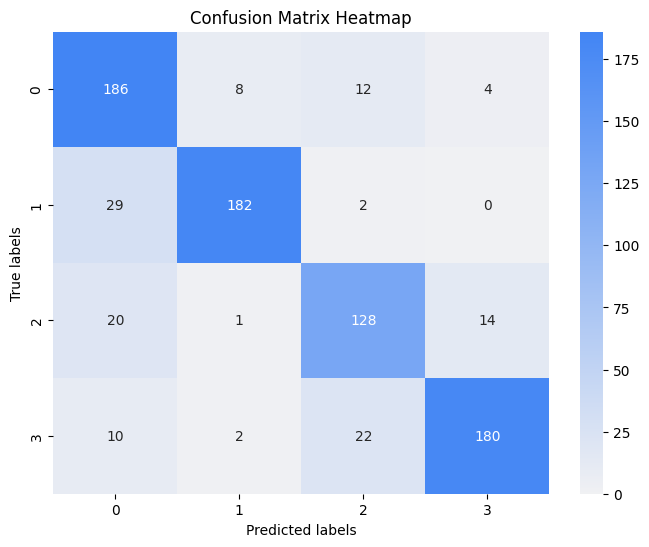

In [13]:
conf_matrix = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="g", cmap=sns.light_palette("#4285f4", as_cmap=True))
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix Heatmap")
plt.show()

## 모델 서빙

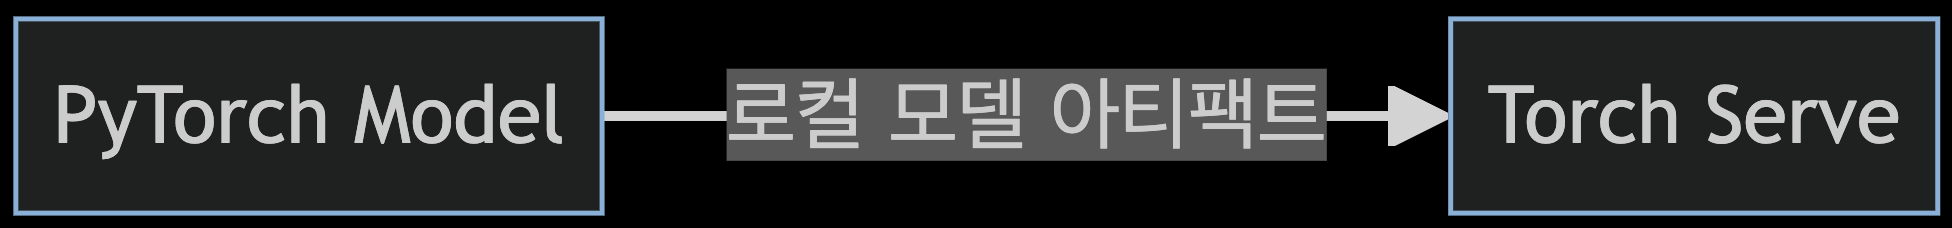


In [14]:
# 모델 체크포인트 저장.
model_save_path = "bert_news_classification_model.pth"
torch.save(model.state_dict(), model_save_path)

In [43]:
%%writefile model_handler.py
import json

import torch
from ts.context import Context
from ts.torch_handler.base_handler import BaseHandler
from transformers import BatchEncoding, BertTokenizer, BertForSequenceClassification

class ModelHandler(BaseHandler):
    def __init__(self):
        self.initialized = False
        self.tokenizer = None
        self.model = None

    def initialize(self, context: Context):
        self.initialized = True
        self.tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
        self.model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)
        self.model.load_state_dict(torch.load("bert_news_classification_model.pth"))
        self.model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
        self.model.eval()

    def preprocess(self, data: list[dict[str, bytearray]]) -> BatchEncoding:
        model_input_texts = sum([item["data"] for item in data], [])
        inputs = self.tokenizer(model_input_texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return inputs.to(device)

    def inference(self, input_batch: BatchEncoding) -> torch.Tensor:
        with torch.no_grad():
            outputs = self.model(**input_batch)
            return outputs.logits

    def postprocess(self, inference_output: torch.Tensor) -> list[dict[str, float]]:
        probabilities = torch.nn.functional.softmax(inference_output, dim=1)
        return [{"label": int(torch.argmax(prob)), "probability": float(prob.max())} for prob in probabilities]

Overwriting model_handler.py


In [32]:
%%writefile config.properties
inference_address=http://0.0.0.0:5000
management_address=http://0.0.0.0:5001
metrics_address=http://0.0.0.0:5002
enable_model_api=true

Overwriting config.properties


In [17]:
# bert vocab 파일 (아티팩트)

!wget https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt \
    -O bert-base-uncased-vocab.txt

--2026-04-15 09:26:12--  https://raw.githubusercontent.com/microsoft/SDNet/master/bert_vocab_files/bert-base-uncased-vocab.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231508 (226K) [text/plain]
Saving to: ‘bert-base-uncased-vocab.txt’

bert-base-uncased-v 100%[===================>] 226.08K  --.-KB/s    in 0.02s   

2026-04-15 09:26:12 (14.6 MB/s) - ‘bert-base-uncased-vocab.txt’ saved [231508/231508]



In [18]:
# Torch serve archiver의 최종 파일 저장 위치.
# .mar 확장자 파일을 생성하여 패키징 하게 된다.

!mkdir -p model-store

In [25]:
!torch-model-archiver \
    --model-name bert_news_classification \
    --version 1.0 \
    --serialized-file bert_news_classification_model.pth \
    --handler ./model_handler.py \
    --extra-files "bert-base-uncased-vocab.txt" \
    --export-path model-store \
    -f

In [44]:
%%script bash --bg
# 서버를 백그라운드에서 실행

PYTHONPATH=/usr/lib/python3.10 torchserve \
    --start \
    --ncs \
    --ts-config config.properties \
    --model-store model-store \
    --models bert_news_classification=bert_news_classification.mar \
    --disable-token-auth

In [45]:
!torchserve --stop

TorchServe has stopped.


In [46]:
!nohup torchserve \
  --start \
  --ts-config config.properties \
  --model-store model-store \
  --models bert_news_classification=bert_news_classification.mar \
  --disable-token-auth > server_log.txt 2>&1 &

In [47]:
import time
time.sleep(10)

In [48]:
!tail -n 50 server_log.txt

2026-04-15T09:44:41,383 [DEBUG] main org.pytorch.serve.wlm.ModelVersionedRefs - Setting default version to 1.0 for model bert_news_classification
2026-04-15T09:44:41,383 [INFO ] main org.pytorch.serve.wlm.ModelManager - Model bert_news_classification loaded.
2026-04-15T09:44:41,383 [DEBUG] main org.pytorch.serve.wlm.ModelManager - updateModel: bert_news_classification, count: 1
2026-04-15T09:44:41,397 [INFO ] main org.pytorch.serve.ModelServer - Initialize Inference server with: EpollServerSocketChannel.
2026-04-15T09:44:41,397 [DEBUG] W-9000-bert_news_classification_1.0 org.pytorch.serve.wlm.WorkerLifeCycle - Worker cmdline: [/usr/bin/python3, /usr/local/lib/python3.12/dist-packages/ts/model_service_worker.py, --sock-type, unix, --sock-name, /tmp/.ts.sock.9000, --metrics-config, /usr/local/lib/python3.12/dist-packages/ts/configs/metrics.yaml]
2026-04-15T09:44:41,540 [INFO ] main org.pytorch.serve.ModelServer - Inference API bind to: http://0.0.0.0:5000
2026-04-15T09:44:41,541 [INFO ] 

In [49]:
# 아래와 같이 뜨면 정상 실행.
# {
#   "status": "Healthy"
# }

!curl -X GET localhost:5000/ping

{
  "status": "Healthy"
}


In [50]:
%%shell

# 모델 실제 평가를 위해 외부 뉴스 기사 데이터 셋 파일 생성.

cat > request_sports.json <<EOF
{
  "data": [
    "Why was Kim Seo-hyeon left on the mound after 7 walks in one inning? Hanwha's self-destruction with 18 walks leads to a comeback loss, erasing a 5-0 lead."
  ]
}
EOF

cat > request_business.json <<EOF
{
  "data": [
    "S&P 500 nears all-time high on hopes for end of conflict. On the 14th (local time), New York stock indices surged across the board as expectations grew for the resumption of peace negotiations between the U.S. and Iran. The S&P 500 rose by more than 1%, approaching the historic 7,000 mark."
  ]
}
EOF

cat > request_sci_tech.json <<EOF
{
  "data": [
    "U.S. pushes nuclear energy forward; China builds mega data centers in western deserts. Control over infrastructure dictates national power as AI power consumption spins 'out of control.'"
  ]
}
EOF


In [51]:
!curl http://localhost:5001/models

{
  "models": [
    {
      "modelName": "bert_news_classification",
      "modelUrl": "bert_news_classification.mar"
    }
  ]
}


In [54]:
# 스포츠 기사 평가 (레이블: 1)
!curl -X POST \
    -H "Accept: application/json" \
    -T "request_sports.json" \
    http://localhost:5000/predictions/bert_news_classification

{
  "label": 1,
  "probability": 0.9929171800613403
}

In [55]:
# 비즈니스 기사 평가 (레이블: 2)
!curl -X POST \
    -H "Accept: application/json" \
    -T "request_business.json" \
    http://localhost:5000/predictions/bert_news_classification

{
  "label": 2,
  "probability": 0.9794437885284424
}

In [56]:
# 테크 기사 평가 (레이블: 3)
!curl -X POST \
    -H "Accept: application/json" \
    -T "request_sci_tech.json" \
    http://localhost:5000/predictions/bert_news_classification

{
  "label": 2,
  "probability": 0.6026692390441895
}

## ngrok을 통한 외부 연결

ngrok은 로컬에 서비스되는 데몬/서버에 외부 도메인을 연결시켜,
외부에서 접근하기 쉽도록 만들어주는 서비스입니다.

5000번으로 호스팅한 서빙 서버 접근을 위해 아래 코드에서는 ngrok을 연결합니다.

In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("2aT0pKF7B5b3u8cQbsDoj12qdZs_52zPrJtqRW9dAGC3w6VFW")
inference_tunnel = ngrok.connect("5000")
inference_tunnel

In [ ]:
!curl -X POST \
    -H "Accept: application/json" \
    -T "request_sci_tech.json" \
    https://1c1d-34-29-238-199.ngrok-free.app/predictions/bert_news_classification

## 회고:
마지막 tech 기사는 못 맞췄지만, 나머지는 높은 확률로 맞다고 추론한 것을 볼 수 있다. 내가 잘 못한건지 에러를 못 잡길래, 퍼실님이 작성해주신 트러블슈팅이랑 ai 도움받아 열심히 수정하고 또 수정했다. 역시나 쉽지 않다. 그래도 새로운 기술들, 기능들을 하나둘씩 배워나가는 재미가 있어서 좋았다.<br><br>

1. 서버 실행 문제.<br>
→ 기존 코드에도 서버 실행 코드는 있었지만 실행 방식이나 순서 문제로 서버가 실제로 떠 있지 않았던 상황이었다.<br>
TorchServe를 먼저 실행하고 sleep으로 충분히 대기한 뒤 curl 요청을 보내는 순서로 수정하여 해결했다.

2. handler 입력 파싱 문제.<br>
기존 코드 : json.loads(item.get("body").decode("utf-8"))["data"] <br>
TorchServe 요청은 항상 저 구조가 아니라고 한다. 이미 dict 형태로 들어오는 경우도 있음. 그래서 충돌 발생 → 503<br>
요청 데이터가 dict인지 bytes인지 구분하여 모두 처리하도록 코드를 수정해 입력 구조를 유연하게 받아들이도록 해결했다.